### Imports

In [4]:
import os, json, sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

### Load experiment results

In [5]:
results_dir = "../outputs/experiment_results"

with open(os.path.join(results_dir, "results_lambda.json"), "r") as f:
    results_lambda = json.load(f)

### Plot

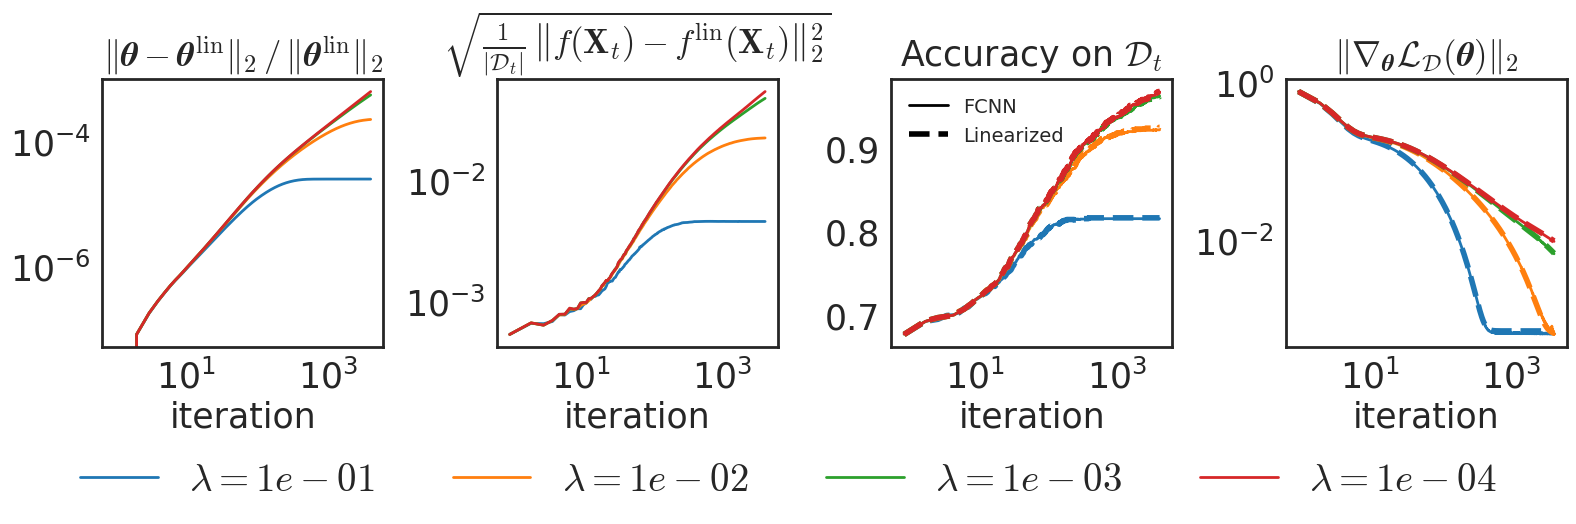

In [6]:
figures_dir = "../outputs/figures"
os.makedirs(figures_dir, exist_ok=True)

rc_tex = {
    "text.usetex": False,
    "mathtext.fontset": "cm",
}

with plt.rc_context(rc_tex), sns.axes_style("white"), sns.plotting_context("paper", font_scale=1.5):
    fig, axs = plt.subplots(1, 4, figsize=(16, 5.2), sharex=False)

    handles = []
    labels = []

    for r in results_lambda:
        lam = r["lam"]
        it = r["iters"]

        h0, = axs[0].plot(it, r["rels"], linewidth=2)
        axs[1].plot(it, r["rmses"], color=h0.get_color(), linewidth=2)
        axs[2].plot(it, r["accs_nn"], color=h0.get_color(), linewidth=2)
        axs[2].plot(it, r["accs_lin"], linestyle="--", linewidth=4, color=h0.get_color())
        axs[3].plot(it, r["gnorms_nn"], color=h0.get_color(), linewidth=2)
        axs[3].plot(it, r["gnorms_lin"], linestyle="--", linewidth=4, color=h0.get_color())

        handles.append(h0)
        labels.append(rf"$\lambda={lam:.0e}$")

    # font sizes
    title_fs = 25
    label_fs = 25
    tick_fs = 25
    legend_fs = 28

    # formatting
    for ax in axs:
        ax.set_xscale("log")
        ax.set_xlabel("iteration", fontsize=label_fs)

        for spine in ax.spines.values():
            spine.set_linewidth(2.0)

        ax.tick_params(axis="both", labelsize=tick_fs, width=1.5)

    axs[0].set_yscale("log")
    axs[0].set_title(
        r"$\|\boldsymbol{\theta}-\boldsymbol{\theta}^\text{lin}\|_2 \,/\, \|\boldsymbol{\theta}^\text{lin}\|_2$",
        pad=10,
        fontsize=title_fs,
    )

    axs[1].set_yscale("log")
    axs[1].set_title(
        r"$\sqrt{\frac{1}{|\mathcal{D}_t|}\,\left\|f(\mathbf{X}_t)-f^{\mathrm{lin}}(\mathbf{X}_t)\right\|_2^2}$",
        pad=18,
        fontsize=title_fs,
    )

    axs[2].set_title(r"Accuracy on $\mathcal{D}_t$", pad=10, fontsize=title_fs)

    all_acc = np.concatenate([r["accs_nn"] for r in results_lambda] + [r["accs_lin"] for r in results_lambda])
    amin, amax = float(all_acc.min()), float(all_acc.max())
    pad = max(0.002, 0.05 * (amax - amin) if amax > amin else 0.002)
    axs[2].set_ylim(amin - pad, amax + pad)

    axs[3].set_yscale("log")
    axs[3].set_title(
        r"$\|\nabla_{\boldsymbol{\theta}}\mathcal{L}_{\mathcal{D}}(\boldsymbol{\theta})\|_2$",
        pad=10,
        fontsize=title_fs,
    )

    style_handles = [
        Line2D([0], [0], color="k", linestyle="-", linewidth=2, label="FCNN"),
        Line2D([0], [0], color="k", linestyle="--", linewidth=4, label="Linearized"),
    ]

    axs[2].legend(handles=style_handles, loc="best", fontsize=14, frameon=False)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=len(results_lambda),
        frameon=False,
        bbox_to_anchor=(0.5, -0.05),
        fontsize=legend_fs,
    )

    fig.tight_layout(rect=(0, 0.1, 1, 1))

    fig.savefig(os.path.join(figures_dir, "figure_2.pdf"), bbox_inches="tight")

    plt.show()